# 🎲 Simulación de Montecarlo

## ¿Por qué Montecarlo?
El modelo de costos de la fase anterior calcula la rentabilidad asumiendo valores
fijos para todas las variables. Pero en la realidad argentina, variables como el
precio del combustible, el tipo de cambio o la cantidad de km diarios son inciertas
y fluctúan constantemente.

La **simulación de Montecarlo** resuelve esto: en lugar de calcular una vez con
valores fijos, simula 10.000 escenarios posibles donde cada variable toma un valor
aleatorio dentro de una distribución probabilística realista.

El resultado no es un número único sino una **distribución de probabilidad** que
responde preguntas como:
- ¿Cuál es la probabilidad de que el VW Gol genere más de $800 USD mensuales?
- ¿Qué auto es más resiliente ante una devaluación brusca?
- ¿Cuál es el peor escenario posible para cada modelo?

## Variables inciertas que vamos a simular
| Variable | Distribución | Justificación |
|---|---|---|
| Precio nafta | Normal | Sube gradualmente con volatilidad moderada |
| Precio GNC | Normal | Similar comportamiento al de la nafta |
| Km diarios | Normal | Varía según demanda, clima, zona |
| Tipo de cambio | Normal | Alta volatilidad en Argentina |
| Ingreso bruto | Triangular | Tiene un mínimo, máximo y valor más probable |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import sys
sys.path.append("..")
from src.modelo import PARAMETROS, MANTENIMIENTO_POR_KM_ARS

np.random.seed(42)  # reproducibilidad
N_SIMULACIONES = 10_000

# Parámetros base
p = PARAMETROS

# Definición de distribuciones para cada variable incierta
# Normal(media, desvio_estandar)
distribuciones = {
    "precio_nafta":    {"dist": "normal", "media": p["precio_nafta_ars_litro"],     "std": p["precio_nafta_ars_litro"] * 0.15},
    "precio_gnc":      {"dist": "normal", "media": p["precio_gnc_ars_m3"],          "std": p["precio_gnc_ars_m3"] * 0.15},
    "km_diarios":      {"dist": "normal", "media": p["km_diarios"],                 "std": 20},
    "tipo_cambio":     {"dist": "normal", "media": 1420,                            "std": 150},
    "ingreso_bruto":   {"dist": "triangular", "min": 600_000, "moda": 2_000_000, "max": 2_800_000},
}

print("Distribuciones configuradas:")
for var, config in distribuciones.items():
    print(f"  {var}: {config}")

Distribuciones configuradas:
  precio_nafta: {'dist': 'normal', 'media': 2034, 'std': 305.09999999999997}
  precio_gnc: {'dist': 'normal', 'media': 500, 'std': 75.0}
  km_diarios: {'dist': 'normal', 'media': 150, 'std': 20}
  tipo_cambio: {'dist': 'normal', 'media': 1420, 'std': 150}
  ingreso_bruto: {'dist': 'triangular', 'min': 600000, 'moda': 2000000, 'max': 2800000}


### ¿Por qué estas distribuciones y no otras?

**Normal para precios y km:** la distribución normal es apropiada cuando la variable
fluctúa alrededor de un valor central con igual probabilidad de subir o bajar.
El precio de nafta en Argentina tiene ajustes periódicos pero oscila alrededor
de un valor de referencia — la normal captura eso. Uso un desvío estándar del 15%
que representa escenarios de variación moderada a alta.

**Triangular para ingresos:** a diferencia de la nafta, los ingresos tienen un
piso real (no podés ganar menos de cierto mínimo trabajando 8hs) y un techo
práctico. La distribución triangular es ideal cuando conocés el mínimo, máximo
y valor más probable — exactamente el caso de los ingresos de un chofer.

**`np.random.seed(42)`:** fijar la semilla hace que la simulación sea
reproducible — cualquier persona que corra este notebook va a obtener exactamente
los mismos resultados. Esto es fundamental en ciencia reproducible.

In [2]:
# Datos de los autos
consumo_por_modelo = {
    "Toyota Etios":        8.5,
    "Toyota Corolla":      9.0,
    "Toyota Yaris":        8.0,
    "Chevrolet Prisma":    8.5,
    "Chevrolet Onix Plus": 7.8,
    "Renault Logan":       8.0,
    "Nissan Versa":        9.0,
    "VW Virtus":           8.5,
    "VW Voyage":           9.5,
    "VW Gol":              9.0,
    "Ford Ka":             8.0,
    "Ford Fiesta":         9.0,
    "Fiat Siena":          9.5,
    "Fiat Cronos":         8.4,
    "Peugeot 208":         7.5,
}

tiene_gnc = {
    "Toyota Etios":        False,
    "Toyota Corolla":      False,
    "Toyota Yaris":        False,
    "Chevrolet Prisma":    True,
    "Chevrolet Onix Plus": False,   # motor turbo — no recomendado para GNC
    "Renault Logan":       True,
    "Nissan Versa":        False,
    "VW Virtus":           False,
    "VW Voyage":           True,
    "VW Gol":              True,
    "Ford Ka":             False,
    "Ford Fiesta":         False,
    "Fiat Siena":          True,
    "Fiat Cronos":         True,    # muy común con GNC en apps de transporte
    "Peugeot 208":         False,
}

df = pd.read_csv("../data/processed/precios_autos_procesado.csv")
precio_mediano = df.groupby("modelo")["precio_usd"].median()

def simular_modelo(precio_compra_usd, consumo_l_100km, gnc, mant_km, n=N_SIMULACIONES):
    # Samplear variables inciertas
    nafta   = np.random.normal(distribuciones["precio_nafta"]["media"],
                               distribuciones["precio_nafta"]["std"], n)
    gnc_p   = np.random.normal(distribuciones["precio_gnc"]["media"],
                               distribuciones["precio_gnc"]["std"], n)
    km_dia  = np.abs(np.random.normal(distribuciones["km_diarios"]["media"],
                                      distribuciones["km_diarios"]["std"], n))
    tc      = np.abs(np.random.normal(distribuciones["tipo_cambio"]["media"],
                                      distribuciones["tipo_cambio"]["std"], n))
    ingreso = np.random.triangular(distribuciones["ingreso_bruto"]["min"],
                                   distribuciones["ingreso_bruto"]["moda"],
                                   distribuciones["ingreso_bruto"]["max"], n)

    km_mes = km_dia * p["dias_laborales_mes"]

    # Combustible
    if gnc:
        costo_comb = (km_mes / 100) * 10 * gnc_p
    else:
        costo_comb = (km_mes / 100) * consumo_l_100km * nafta

    # Amortización con valor residual (el auto no vale $0 al final)
    precio_ars = precio_compra_usd * tc
    amort = (precio_ars * (1 - p["valor_residual_pct"]) / p["vida_util_km"]) * km_mes

    # Mantenimiento por km (cubiertas, frenos, service, etc.)
    mantenimiento = mant_km * km_mes

    # Seguro y patente proporcionales al valor del auto
    seguro  = np.maximum(precio_ars * p["seguro_pct_mensual"], p["seguro_piso_ars"])
    patente = (precio_ars * p["valor_fiscal_pct"] * p["patente_pct_anual"]) / 12

    # Ingresos netos Cabify
    ingreso_neto = ingreso * (1 - p["comision_cabify"])

    # Ganancia neta en USD
    ganancia_ars = ingreso_neto - costo_comb - amort - mantenimiento - seguro - patente
    ganancia_usd = ganancia_ars / tc

    return ganancia_usd

# Correr simulación para todos los modelos
resultados_mc = {}
for modelo in consumo_por_modelo:
    precio = precio_mediano[modelo]
    resultados_mc[modelo] = simular_modelo(
        precio_compra_usd=precio,
        consumo_l_100km=consumo_por_modelo[modelo],
        gnc=tiene_gnc[modelo],
        mant_km=MANTENIMIENTO_POR_KM_ARS[modelo]
    )

print(f"Simulación completada: {N_SIMULACIONES:,} escenarios × {len(resultados_mc)} modelos")
print(f"Total de cálculos: {N_SIMULACIONES * len(resultados_mc):,}")

Simulación completada: 10,000 escenarios × 15 modelos
Total de cálculos: 150,000


### Resumen estadístico de la simulación

Para cada modelo extraemos tres percentiles clave:
- **P10 (pesimista):** el 10% de los escenarios son peores que este valor
- **P50 (mediana):** escenario típico
- **P90 (optimista):** el 10% de los escenarios son mejores que este valor

El **P10 es el indicador más importante para la decisión de compra** — te dice
cuánto ganás en el peor escenario probable, no en el ideal.

In [3]:
# Resumen estadístico
resumen = []
for modelo, ganancias in resultados_mc.items():
    resumen.append({
        "modelo": modelo,
        "gnc": tiene_gnc[modelo],
        "p10_usd": np.percentile(ganancias, 10),
        "p50_usd": np.percentile(ganancias, 50),
        "p90_usd": np.percentile(ganancias, 90),
        "media_usd": np.mean(ganancias),
        "std_usd": np.std(ganancias),
        "prob_positivo": np.mean(ganancias > 0) * 100,
    })

df_mc = pd.DataFrame(resumen).set_index("modelo").sort_values("p50_usd", ascending=False)
print(df_mc.round(1).to_string())

                       gnc  p10_usd  p50_usd  p90_usd  media_usd  std_usd  prob_positivo
modelo                                                                                  
Fiat Siena            True    141.6    569.5    933.4      554.1    300.9           96.4
VW Voyage             True     81.3    519.4    881.8      502.5    302.3           94.4
Chevrolet Prisma      True     78.5    510.2    893.4      498.5    307.5           93.8
VW Gol                True     79.0    501.5    879.7      491.2    304.2           94.2
Renault Logan         True     55.0    485.7    860.7      474.2    305.0           92.9
Fiat Cronos           True    -67.5    363.9    747.8      351.8    306.7           85.9
Ford Ka              False   -244.9    198.5    580.1      185.3    315.6           72.2
Ford Fiesta          False   -343.6    108.8    495.5       92.5    320.5           62.3
Toyota Etios         False   -378.8     67.7    457.0       54.4    318.7           57.8
Chevrolet Onix Plus  

### Visualización de distribuciones

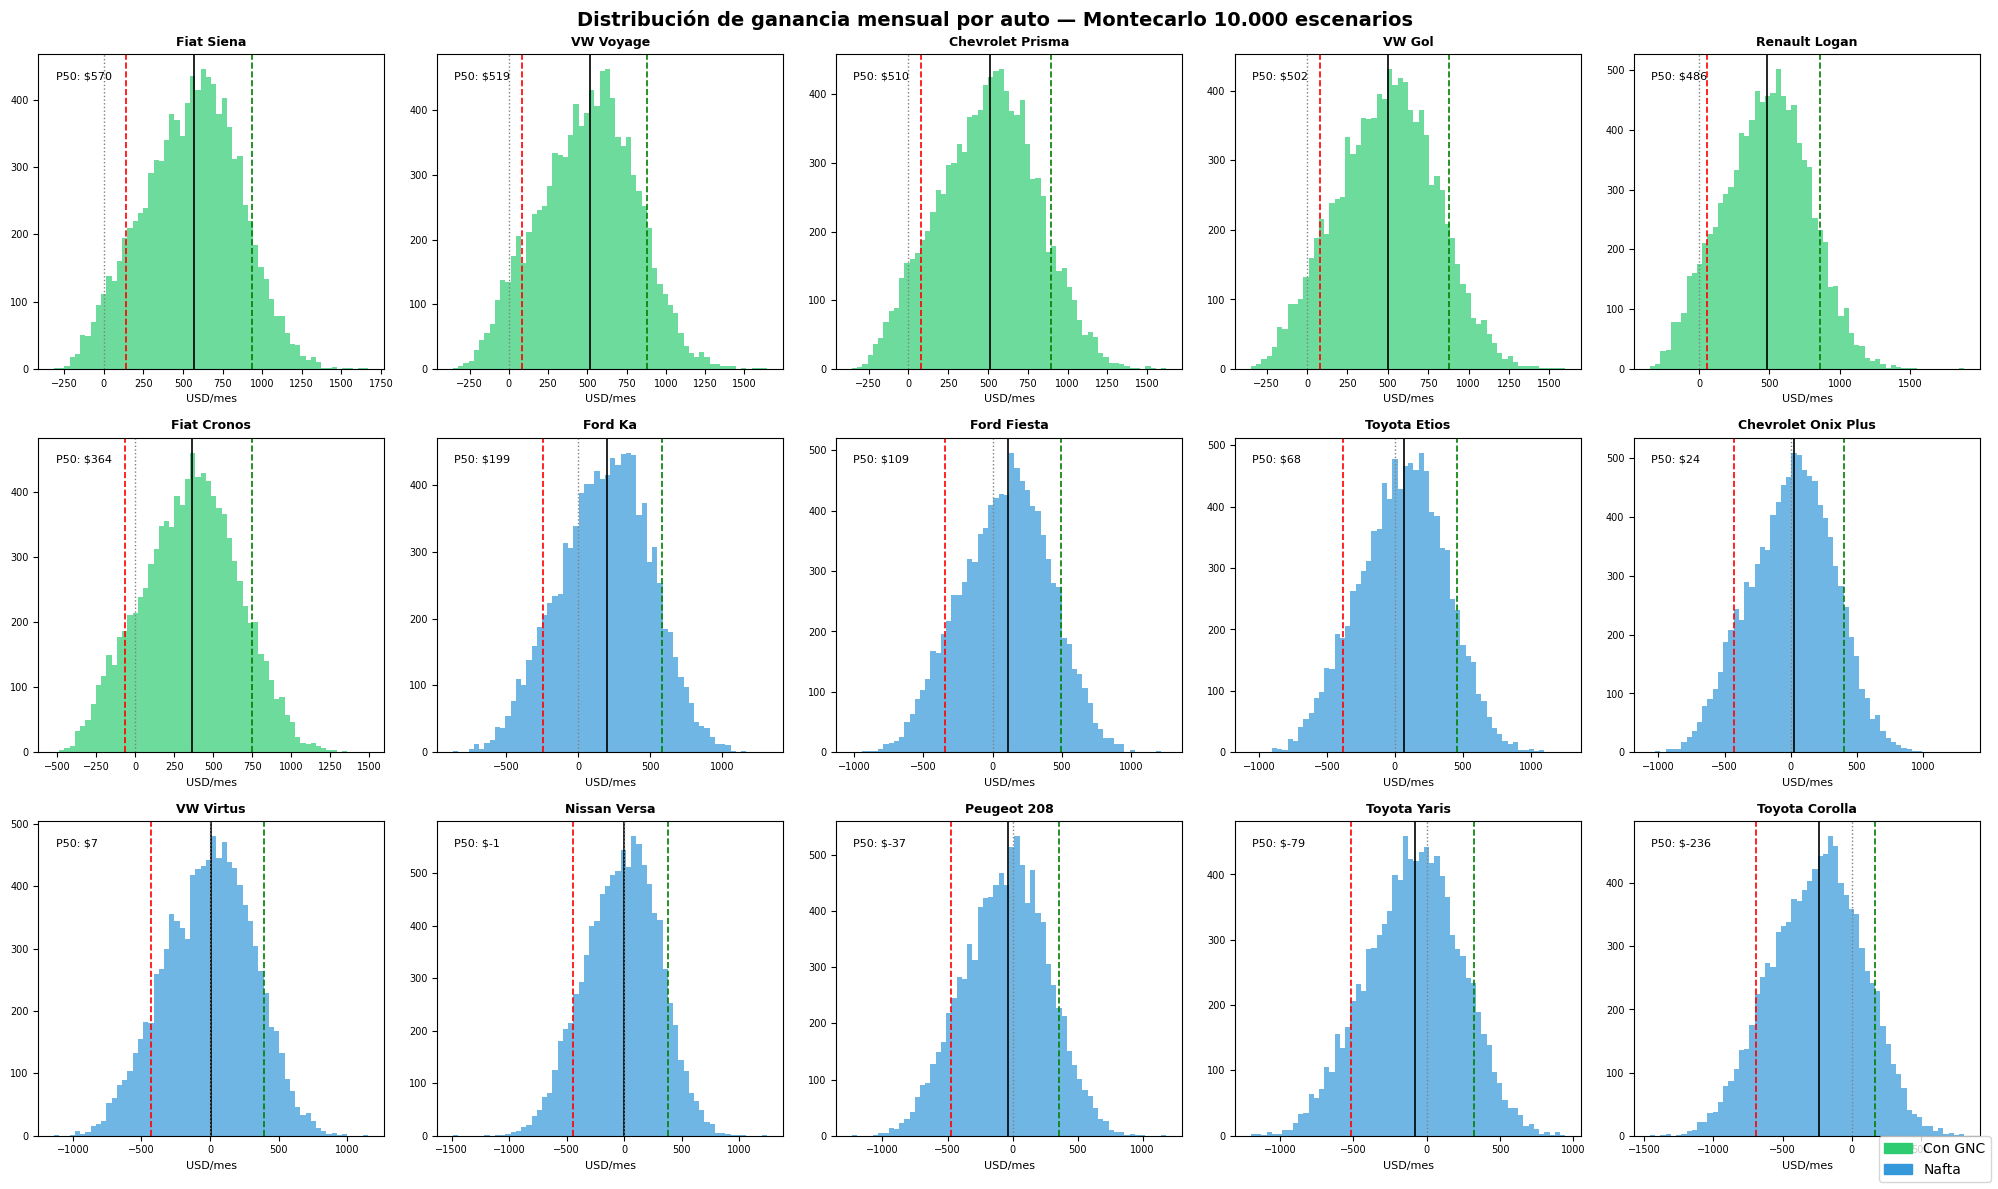

Gráfico guardado.


In [4]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle("Distribución de ganancia mensual por auto — Montecarlo 10.000 escenarios",
             fontsize=14, fontweight="bold")

modelos_orden = df_mc.index.tolist()
axes_flat = axes.flatten()

for i, modelo in enumerate(modelos_orden):
    ax = axes_flat[i]
    ganancias = resultados_mc[modelo]
    color = "#2ecc71" if tiene_gnc[modelo] else "#3498db"

    ax.hist(ganancias, bins=60, color=color, alpha=0.7, edgecolor="none")
    ax.axvline(np.percentile(ganancias, 10),  color="red",    linestyle="--", linewidth=1.2, label="P10")
    ax.axvline(np.percentile(ganancias, 50),  color="black",  linestyle="-",  linewidth=1.2, label="P50")
    ax.axvline(np.percentile(ganancias, 90),  color="green",  linestyle="--", linewidth=1.2, label="P90")
    ax.axvline(0, color="gray", linestyle=":", linewidth=1)

    ax.set_title(modelo, fontsize=9, fontweight="bold")
    ax.set_xlabel("USD/mes", fontsize=8)
    ax.tick_params(labelsize=7)

    p50 = np.percentile(ganancias, 50)
    ax.text(0.05, 0.92, f"P50: ${p50:,.0f}", transform=ax.transAxes,
            fontsize=8, color="black")

# Ocultar subplots sobrantes si hay menos modelos que celdas en la grilla
for j in range(len(modelos_orden), len(axes_flat)):
    axes_flat[j].set_visible(False)

patch_gnc   = mpatches.Patch(color="#2ecc71", label="Con GNC")
patch_nafta = mpatches.Patch(color="#3498db", label="Nafta")
fig.legend(handles=[patch_gnc, patch_nafta], loc="lower right", fontsize=10)

plt.tight_layout()
plt.savefig("../reports/figures/03_montecarlo_distribuciones.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado.")

### Comparación de kilometraje entre los modelos GNC líderes

Para validar que la diferencia de rentabilidad entre Fiat Siena, VW Voyage y
Chevrolet Prisma no se explica por diferencias en el estado del auto, comparé
sus kilometrajes medianos:

| Modelo | Km medianos | Precio mediano (USD) | P50 ganancia |
|---|---|---|---|
| Fiat Siena | 124.500 km | $8.653 | $570/mes |
| VW Voyage | 110.000 km | $9.867 | $519/mes |
| Chevrolet Prisma | 110.000 km | $9.933 | $510/mes |

Los tres tienen kilometrajes del mismo orden — el GNC los iguala en costo de
combustible y sus costos de mantenimiento por km son similares (80-90 ARS/km).
La diferencia de rentabilidad se explica **principalmente por el precio de
entrada**, que en el modelo v2 pega triple: amortización, seguro y patente son
proporcionales al valor del auto. El Fiat Siena gana porque es el más barato,
incluso siendo el de mayor kilometraje del grupo.

### Interpretación de la simulación de Montecarlo (modelo v2)

Los 6 modelos con GNC dominan el ranking con P50 entre $364 y $570 USD/mes,
muy por encima de los autos a nafta que van de $199 a **valores negativos**.
Con el modelo v2 (mantenimiento, seguro y patente realistas), cuatro autos a
nafta tienen P50 negativo o casi nulo: Nissan Versa (-$2), Peugeot 208 (-$37),
Toyota Yaris (-$79) y Toyota Corolla (-$236). En el escenario mediano, esos
autos pierden plata trabajando en Cabify.

**Hallazgo clave:** el Fiat Siena, VW Voyage y Chevrolet Prisma tienen costos
de combustible idénticos (GNC), por lo que la diferencia entre ellos se explica
casi exclusivamente por el precio de entrada:

| Auto | Precio mediano | P50 ganancia | Prob. mes positivo |
|---|---|---|---|
| Fiat Siena | $8.653 USD | $570 USD/mes | 96,4% |
| VW Voyage | $9.867 USD | $519 USD/mes | 94,4% |
| Chevrolet Prisma | $9.933 USD | $510 USD/mes | 93,8% |

**Sobre el riesgo:** la brecha GNC-nafta ahora también es una brecha de
viabilidad. Los 5 GNC baratos mantienen probabilidad de mes positivo superior
al 92%, mientras que el mejor auto a nafta (Ford Ka) baja a 72% y el Toyota
Corolla a apenas 23% — trabajar con un Corolla en Cabify es perder plata 3 de
cada 4 meses. Incluso el Fiat Cronos, con GNC pero caro, tiene P10 negativo
(-$68): el precio de entrada alto le quita el colchón que tienen los otros GNC.

### Análisis de sensibilidad — ¿Qué variable impacta más la rentabilidad?

Hasta ahora simulamos todas las variables inciertas juntas. Pero una pregunta
clave es: **¿cuál de todas es la que más afecta la ganancia mensual?**

El **análisis de sensibilidad** responde esto. La metodología es simple:
variamos una variable a la vez (manteniendo el resto fija en su valor base)
y medimos cuánto cambia la ganancia. La variable que genera el mayor cambio
es la más crítica.

El resultado se visualiza en un **tornado chart** — se llama así porque las
barras ordenadas de mayor a menor impacto tienen forma de tornado. Es el
gráfico estándar de análisis de sensibilidad en finanzas y DS.

**¿Por qué importa esto?** Porque le dice al conductor dónde concentrar su
atención. Si el precio de nafta es la variable más crítica, la decisión más
importante es GNC sí o no. Si son los km diarios, la clave es maximizar las
horas trabajadas.

        variable  impacto_alto  impacto_bajo  impacto_total
          Seguro         -20.8          20.8           41.5
Precio nafta/GNC         -27.5          27.5           54.9
Precio de compra         -40.6          25.1           65.6
   Mantenimiento         -43.9          43.9           87.9
      Km diarios         -86.0          86.0          172.1
  Tipo de cambio        -145.9         199.4          345.3
   Ingreso bruto         246.5        -246.5          493.0


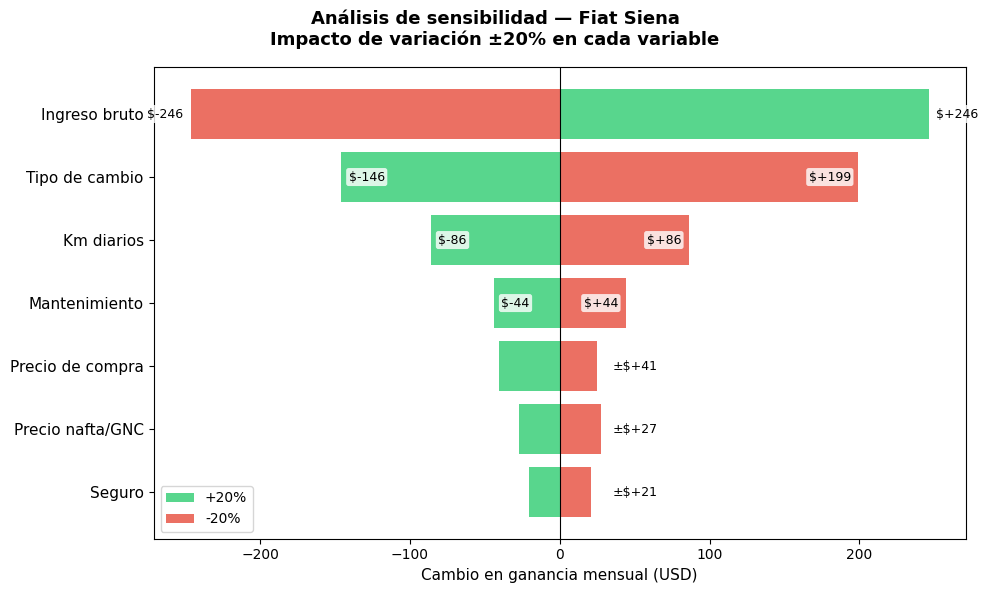

Gráfico guardado.


In [5]:
# Análisis de sensibilidad para el modelo ganador
# Variamos cada variable ±20% y medimos el impacto en ganancia (modelo v2)

modelo_ref = "Fiat Siena"
precio_ref = precio_mediano[modelo_ref]
consumo_ref = consumo_por_modelo[modelo_ref]
gnc_ref = tiene_gnc[modelo_ref]
mant_ref = MANTENIMIENTO_POR_KM_ARS[modelo_ref]
VARIACION = 0.20

def ganancia_base(precio_compra, km_dia, tc, ingreso, nafta, gnc_precio,
                  mant_km, seguro_factor=1.0):
    km_mes = km_dia * p["dias_laborales_mes"]
    if gnc_ref:
        costo_comb = (km_mes / 100) * 10 * gnc_precio
    else:
        costo_comb = (km_mes / 100) * consumo_ref * nafta
    precio_ars = precio_compra * tc
    amort = (precio_ars * (1 - p["valor_residual_pct"]) / p["vida_util_km"]) * km_mes
    mantenimiento = mant_km * km_mes
    seguro = max(precio_ars * p["seguro_pct_mensual"], p["seguro_piso_ars"]) * seguro_factor
    patente = (precio_ars * p["valor_fiscal_pct"] * p["patente_pct_anual"]) / 12
    ingreso_neto = ingreso * (1 - p["comision_cabify"])
    ganancia_ars = ingreso_neto - costo_comb - amort - mantenimiento - seguro - patente
    return ganancia_ars / tc

# Valores base
base_args = dict(
    precio_compra=precio_ref,
    km_dia=p["km_diarios"],
    tc=1420,
    ingreso=p["ingreso_bruto_mensual_ars"],
    nafta=p["precio_nafta_ars_litro"],
    gnc_precio=p["precio_gnc_ars_m3"],
    mant_km=mant_ref,
)

ganancia_central = ganancia_base(**base_args)

# Qué argumentos varía cada escenario. "Precio de compra" arrastra también
# seguro y patente (son proporcionales al valor del auto) — es intencional.
variaciones_map = {
    "Precio nafta/GNC": ("nafta", "gnc_precio"),
    "Km diarios":       ("km_dia",),
    "Tipo de cambio":   ("tc",),
    "Ingreso bruto":    ("ingreso",),
    "Precio de compra": ("precio_compra",),
    "Mantenimiento":    ("mant_km",),
    "Seguro":           ("seguro_factor",),
}

sensibilidad = []
for nombre, keys in variaciones_map.items():
    args_high = base_args.copy()
    args_low  = base_args.copy()

    for k in keys:
        if k == "seguro_factor":
            args_high[k] = 1 + VARIACION
            args_low[k]  = 1 - VARIACION
        else:
            args_high[k] = base_args[k] * (1 + VARIACION)
            args_low[k]  = base_args[k] * (1 - VARIACION)

    g_high = ganancia_base(**args_high)
    g_low  = ganancia_base(**args_low)

    sensibilidad.append({
        "variable": nombre,
        "impacto_alto": g_high - ganancia_central,
        "impacto_bajo": g_low  - ganancia_central,
        "impacto_total": abs(g_high - ganancia_central) + abs(g_low - ganancia_central)
    })

df_sens = pd.DataFrame(sensibilidad).sort_values("impacto_total", ascending=True)
print(df_sens.round(1).to_string(index=False))

# Tornado chart
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle(f"Análisis de sensibilidad — {modelo_ref}\nImpacto de variación ±20% en cada variable",
             fontsize=13, fontweight="bold")

y_pos = range(len(df_sens))
ax.barh(y_pos, df_sens["impacto_alto"], color="#2ecc71", alpha=0.8, label="+20%")
ax.barh(y_pos, df_sens["impacto_bajo"], color="#e74c3c", alpha=0.8, label="-20%")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(df_sens["variable"], fontsize=11)
ax.set_xlabel("Cambio en ganancia mensual (USD)", fontsize=11)
ax.legend(fontsize=10)

for i, row in enumerate(df_sens.itertuples()):
    impacto_total = abs(row.impacto_alto) + abs(row.impacto_bajo)
    
    if impacto_total > 80:  # barras grandes — label afuera
        ax.text(row.impacto_alto + 5, i, f"${row.impacto_alto:+.0f}",
                va="center", fontsize=9, color="black",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8, edgecolor="none"))
        ax.text(row.impacto_bajo - 5, i, f"${row.impacto_bajo:+.0f}",
                va="center", fontsize=9, color="black", ha="right",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8, edgecolor="none"))
    else:  # barras chicas — un solo label a la derecha
        ax.text(35, i, f"±${abs(row.impacto_alto):+.0f}",
                va="center", fontsize=9, color="black",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8, edgecolor="none"))

plt.tight_layout()
plt.savefig("../reports/figures/04_sensibilidad_tornado.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado.")

### Interpretación del análisis de sensibilidad (modelo v2)

El tornado chart revela el orden de impacto de cada variable sobre la rentabilidad
del Fiat Siena ante una variación del ±20%:

1. **Ingreso bruto (±$246 USD):** la variable de mayor impacto. La rentabilidad
   depende más de cuánto trabajás que de cualquier costo externo. Un mes flojo
   de viajes impacta más que una suba de cualquier costo.

2. **Tipo de cambio (-$146/+$199 USD):** segunda variable más crítica y asimétrica —
   una devaluación del peso beneficia al conductor porque sus costos fijos en ARS
   valen menos en dólares, por lo que su ganancia medida en USD sube. Esto es un
   efecto paradójico típico de la economía argentina.

3. **Km diarios (±$86 USD):** el impacto creció respecto al modelo v1 porque
   ahora cada km arrastra también mantenimiento (80 ARS/km), además de
   combustible y amortización. Con ingreso fijo en este análisis, más km es
   más costo neto.

4. **Mantenimiento (±$44 USD):** la nueva variable del modelo v2 entra cuarta —
   más relevante que el combustible para un auto con GNC. Errar la estimación
   de mantenimiento en 20% mueve la ganancia más que una suba del GNC.

5. **Precio de compra (-$41/+$25 USD), nafta/GNC (±$28) y seguro (±$21):**
   impacto menor. El precio de compra es asimétrico porque el seguro tiene un
   piso de $140.000: abaratar el auto deja de ahorrar seguro en algún punto.

**Conclusión clave:** el conductor tiene más poder sobre su rentabilidad
optimizando sus horas de trabajo que preocupándose por los costos del auto —
pero en el modelo v2, mantener el auto barato de operar (GNC + mantenimiento
económico) pasó de detalle a condición de viabilidad.